# 1 Проверка связи частотного и классического определения вероятности с помощью моделирования

Вспомним. Частотное определение вероятности построено на эксперименте и предполагает бесконечное количество испытаний.

Пусть эксперимент проводится $N$ раз ($N \rightarrow \infty$), $N_A$ — количество исходов, когда событие $A$ произошло, тогда вероятность события $A$ определяется как отношение $N_A$ к $N$ при $N \rightarrow \infty$:

$$P(A) = \lim_{N \rightarrow \infty} \frac{N_A}{N}$$

## 1.1 Задача (подбрасывание кубика)
Требуется оценить вероятность выпадения 1 при подбрасывании игрального кубика с помощью классической и частотной вероятности (из 100 000 000 испытаний).

Пользуясь классическим определением, получим:
$$p = \frac{1}{6} = 0.1(6)$$

Оценим частоту выпадения 1 очка при 100 000 000 подбрасываниях игрального кубика.

In [8]:
import numpy as np

number_of_rolls = 100000000
dice_rolls = np.random.randint(1, 7, number_of_rolls)
len(dice_rolls[dice_rolls == 1]) / number_of_rolls
import numpy as np
import plotly.graph_objs as go

# Моделирование сходимости частоты выпадения 1 к вероятности 1/6
N_values = np.array(range(100, 100001, 500))
P_A_values = []

for N in N_values:
    rolls = np.random.randint(1, 7, N)
    freq_1 = np.sum(rolls == 1) / N
    P_A_values.append(freq_1)

P_theory = [1/6] * len(N_values)

fig = go.Figure(layout=dict(width=700, height=350))
fig.add_trace(go.Scatter(x=N_values, y=P_A_values, name='Частота выпадения 1'))
fig.add_trace(go.Scatter(x=N_values, y=P_theory, name='Теоретическая (1/6)', line_dash='dash'))
fig.update_xaxes(title_text='Число испытаний (N)')
fig.update_yaxes(title_text='P(A)')
fig.show()

## 1.2 Задача (красные и синие шарики)
В коробке находится 6 красных и 6 синих шариков. Сколько существует способов вынуть 3 красных и 3 синих шарика?

Пользуясь классическим определением, получим:
$$p = \frac{C_6^3 \cdot C_6^3}{C_{12}^6} = 0.4329$$

Оценим вероятность вынуть 3 красных и 3 синих шарика, используя от 10 до 10000 испытаний.

0.4291


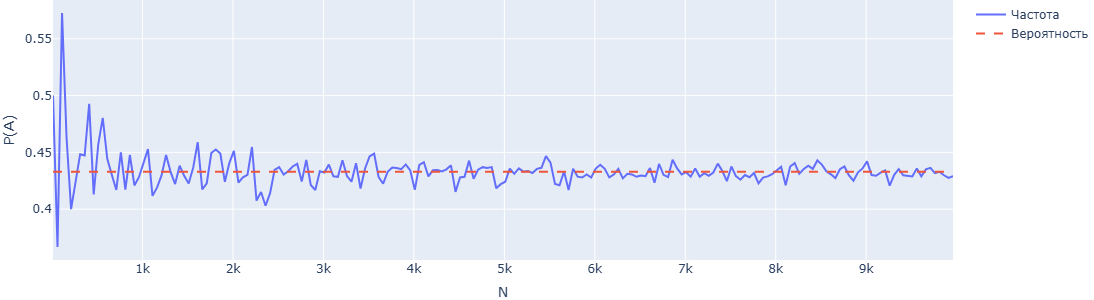

In [9]:
from random import sample
import numpy as np
import plotly.graph_objs as go

def random_combination():
    urna = ['R'] * 6 + ['B'] * 6
    return sample(urna, 6)

N_values = np.array(range(10, 10001, 50))
P_A_values = []

for N in N_values:
    N_A = 0
    for _ in range(N):
        comb = random_combination()
        if comb.count('R') == 3:
            N_A += 1
    P_A_values.append(N_A / N)

print(round(P_A_values[-1], 4))

P = [0.4329] * len(N_values)

fig = go.Figure(layout=dict(width=600, height=300))
fig.update_layout(margin=dict(l=0, t=0, b=0))
fig.add_trace(go.Scatter(x=N_values, y=P_A_values, name='Частота'))
fig.add_trace(go.Scatter(x=N_values, y=P, name='Вероятность', line_dash='dash'))
fig.update_xaxes(title_text='N')
fig.update_yaxes(title_text='P(A)')
fig.show()

## 1.3 Задача (сумма на двух кубиках)
Требуется оценить вероятности всех возможных значений суммы очков, выпадающей на двух игральных костях при одновременном подбрасывании, с помощью классической и частотной вероятности (из 100 000 испытаний).

In [10]:
# классическая вероятность
from itertools import product

ls = list(product('123456', repeat=2))
prob = {}  # словарь сумма вероятность
rec = {s: [] for s in range(2, 13)}

for pair in ls:
    sm = sum(list(map(int, pair)))
    prob[sm] = prob.get(sm, 0) + 1
    rec[sm].append('+'.join(pair))

N = len(ls)
for sm, cnt in prob.items():
    prob[sm] = cnt / N
    variants = '='.join(rec[sm])
    print(f'Сумма {sm}: {variants}, вероятность: {prob[sm]:.4f}.')

Сумма 2: 1+1, вероятность: 0.0278.
Сумма 3: 1+2=2+1, вероятность: 0.0556.
Сумма 4: 1+3=2+2=3+1, вероятность: 0.0833.
Сумма 5: 1+4=2+3=3+2=4+1, вероятность: 0.1111.
Сумма 6: 1+5=2+4=3+3=4+2=5+1, вероятность: 0.1389.
Сумма 7: 1+6=2+5=3+4=4+3=5+2=6+1, вероятность: 0.1667.
Сумма 8: 2+6=3+5=4+4=5+3=6+2, вероятность: 0.1389.
Сумма 9: 3+6=4+5=5+4=6+3, вероятность: 0.1111.
Сумма 10: 4+6=5+5=6+4, вероятность: 0.0833.
Сумма 11: 5+6=6+5, вероятность: 0.0556.
Сумма 12: 6+6, вероятность: 0.0278.


In [11]:
# частотная вероятность
from random import choices

def random_combination():
    return choices([1, 2, 3, 4, 5, 6], k=2)

N = 100_000
freq = {}  # словарь сумма частота

for i in range(N):
    comb = random_combination()
    sm = sum(comb)
    freq[sm] = freq.get(sm, 0) + 1

for sm in sorted(freq.keys()):
    print(f'Сумма {sm}, частота: {freq[sm] / N:.4f}')

Сумма 2, частота: 0.0274
Сумма 3, частота: 0.0560
Сумма 4, частота: 0.0830
Сумма 5, частота: 0.1095
Сумма 6, частота: 0.1393
Сумма 7, частота: 0.1671
Сумма 8, частота: 0.1370
Сумма 9, частота: 0.1132
Сумма 10, частота: 0.0842
Сумма 11, частота: 0.0562
Сумма 12, частота: 0.0271


In [12]:
import pandas as pd

frequency = [freq[sm] / N for sm in sorted(freq.keys())]

df = pd.DataFrame(
    index=prob.keys(),
    data={
        'Вероятность': prob.values(),
        'Частота': frequency
    }
)
df['Отклонение'] = abs(df['Вероятность'] - df['Частота'])
df

,Вероятность,Частота,Отклонение
2,0.027778,0.02739,0.000388
3,0.055556,0.05604,0.000484
4,0.083333,0.08302,0.000313
5,0.111111,0.10949,0.001621
6,0.138889,0.13932,0.000431
7,0.166667,0.16710,0.000433
8,0.138889,0.13696,0.001929
9,0.111111,0.11322,0.002109
10,0.083333,0.08416,0.000827
11,0.055556,0.05618,0.000624


<Axes: >

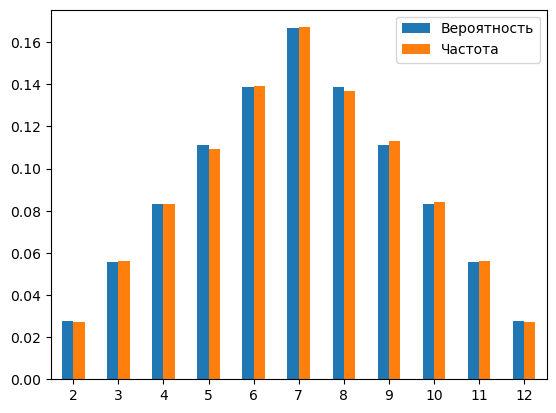

In [13]:
df[['Вероятность', 'Частота']].plot.bar(rot=0)